In [4]:
# Import library yang dibutuhkan
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Load data dari file CSV
data = pd.read_csv("police.csv")

In [ ]:
# **Bagian A: Tampilkan data seperti gambar**
# Menampilkan data dengan format yang serupa
display(data.head(91736))

,state,stop_date,stop_time,county_name,driver_gender,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop,district,year
0,RI,2005-01-04,12:55,NaN,M,White,Equipment/Inspection Violation,Equipment,False,NaN,Citation,False,0-15 Min,False,Zone X4,2005
1,RI,2005-01-23,23:15,NaN,M,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone K3,2005
2,RI,2005-02-17,04:15,NaN,M,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone X4,2005
3,RI,2005-02-20,17:15,NaN,M,White,Call for Service,Other,False,NaN,Arrest Driver,True,16-30 Min,False,Zone X1,2005
4,RI,2005-02-24,01:20,NaN,F,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone X3,2005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91731,RI,2015-12-31,13:23,NaN,M,White,Speeding,Speeding,False,NaN,N/D,False,16-30 Min,False,Zone X1,2015
91732,RI,2015-12-31,18:59,NaN,M,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone K2,2015
91733,RI,2015-12-31,19:13,NaN,M,White,Other Traffic Violation,Moving violation,False,NaN,Citation,False,16-30 Min,False,Zone K3,2015
91734,RI,2015-12-31,20:20,NaN,M,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone K2,2015


In [ ]:
# **Bagian B: Pengecekan jenis kelamin mana yang paling banyak melakukan pelanggaran lalu lintas**
# Menghitung proporsi pelanggaran berdasarkan jenis kelamin
gender_proportion = data['driver_gender'].value_counts(normalize=True)
print("Proporsi pelanggaran berdasarkan jenis kelamin:")
print(gender_proportion)

Proporsi pelanggaran berdasarkan jenis kelamin:
driver_gender
M    0.72527
F    0.27473
Name: proportion, dtype: float64


In [ ]:
# **Bagian C: Pelanggaran yang banyak dilakukan oleh masing-masing jenis kelamin**
# Menghitung proporsi jenis pelanggaran untuk setiap jenis kelamin
violation_proportion = data.groupby(['driver_gender', 'violation']).size().unstack().apply(lambda x: x / x.sum(), axis=1)

print("Proporsi pelanggaran berdasarkan jenis kelamin:")
print(violation_proportion)

Proporsi pelanggaran berdasarkan jenis kelamin:
violation      Equipment  Moving violation     Other  Registration/plates  \
driver_gender                                                               
F               0.105199          0.138218  0.029738             0.044418   
M               0.134158          0.206144  0.058985             0.042175   

violation      Seat belt  Speeding  
driver_gender                       
F               0.024312  0.658114  
M               0.036296  0.522243  


<ipython-input-10-94599e591493>:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['hour'] = pd.to_datetime(data['stop_time'], errors='coerce').dt.hour


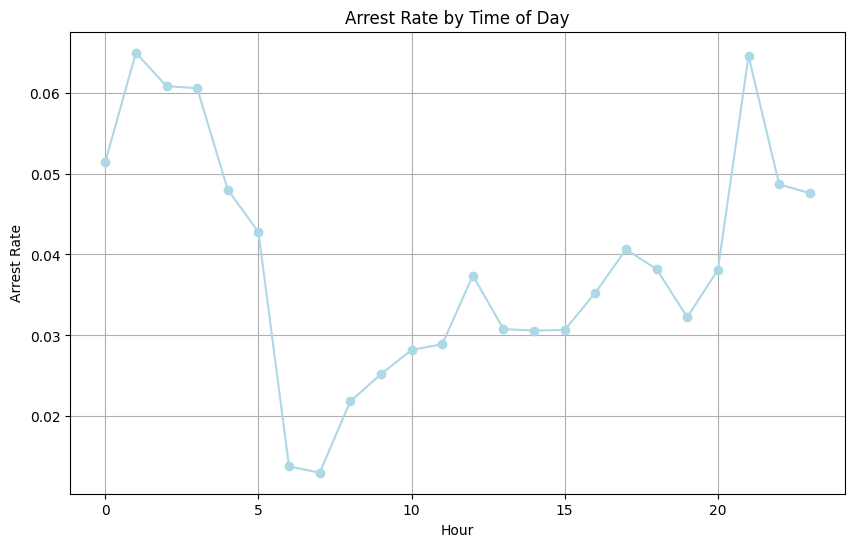

In [ ]:
# **Bagian D: Grafik tingkat penangkapan berdasarkan waktu**
# Pastikan kolom 'time' dan 'is_arrested' ada dalam data

# Tambahkan kolom 'hour' dari waktu penangkapan
data['hour'] = pd.to_datetime(data['stop_time'], errors='coerce').dt.hour

# Hitung tingkat penangkapan per jam
arrest_rate_by_hour = data.groupby('hour')['is_arrested'].mean()

# Plot grafik tingkat penangkapan
plt.figure(figsize=(10, 6))
arrest_rate_by_hour.plot(kind='line', marker='o', title="Arrest Rate by Time of Day", color='#ADD8E6')
plt.xlabel("Hour")
plt.ylabel("Arrest Rate")
plt.grid()
plt.show()

Grafik ini menunjukkan "Tingkat Penangkapan berdasarkan Waktu Hari".

Sumbu X: Mewakili jam dalam sehari, dari 0 hingga 23.
Sumbu Y: Mewakili tingkat penangkapan yang terjadi pada setiap jam.
Dari grafik, terlihat bahwa tingkat penangkapan berfluktuasi sepanjang hari. Ada puncak pada beberapa jam tertentu, sementara pada jam lainnya, tingkat penangkapan tampak lebih rendah.

Pola ini bisa memberikan wawasan tentang waktu-waktu di mana penangkapan cenderung lebih sering terjadi, yang mungkin berkaitan dengan aktivitas tertentu atau kondisi sosial yang berbeda sepanjang hari.

In [ ]:
# **Bagian E: Data penangkapan karena keterkaitannya dengan penangkapan narkoba**
# Filter data penangkapan narkoba
drug_arrests = data[data['drugs_related_stop'] == True]

# Tambahkan kolom 'year' dari tanggal pemberhentian
data['year'] = pd.to_datetime(data['stop_date'], errors='coerce').dt.year

# Hitung proporsi penangkapan narkoba per tahun
drug_arrest_rate = drug_arrests.groupby('year').size() / data.groupby('year').size()



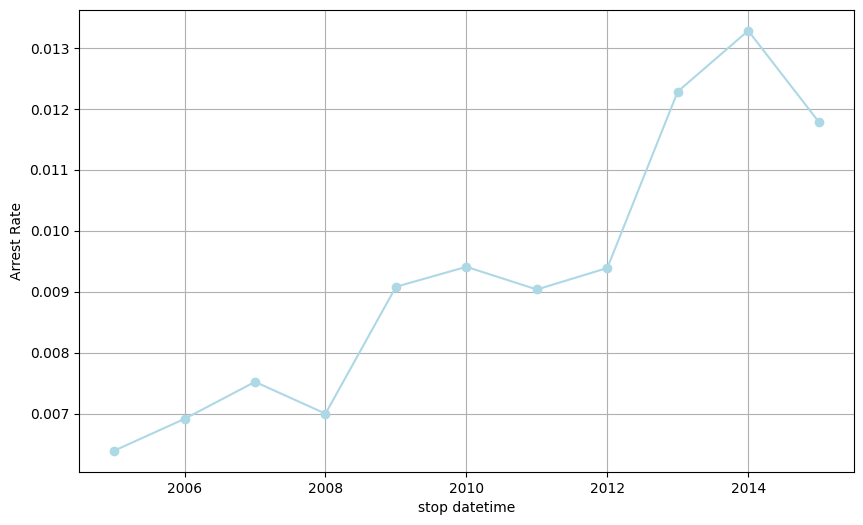

In [ ]:
# Plot data
plt.figure(figsize=(10, 6))
drug_arrest_rate.plot(kind='line', marker='o', color='#ADD8E6')
plt.xlabel("stop datetime")
plt.ylabel("Arrest Rate")
plt.grid()
plt.show()


Grafik ini menunjukkan tren jumlah tertentu dari tahun 2006 hingga 2014.

Sumbu X: Menunjukkan tahun, mulai dari 2006 hingga 2014.
Sumbu Y: Menunjukkan nilai atau jumlah yang diukur, dengan angka yang meningkat seiring waktu.
Terdapat pola yang jelas di mana nilai cenderung meningkat dari tahun ke tahun, dengan beberapa fluktuasi. Terutama setelah 2012, tampak ada lonjakan yang signifikan, meskipun ada penurunan di akhir periode.

Grafik ini memberikan gambaran umum tentang bagaimana jumlah yang diukur telah berubah selama periode waktu tersebut.

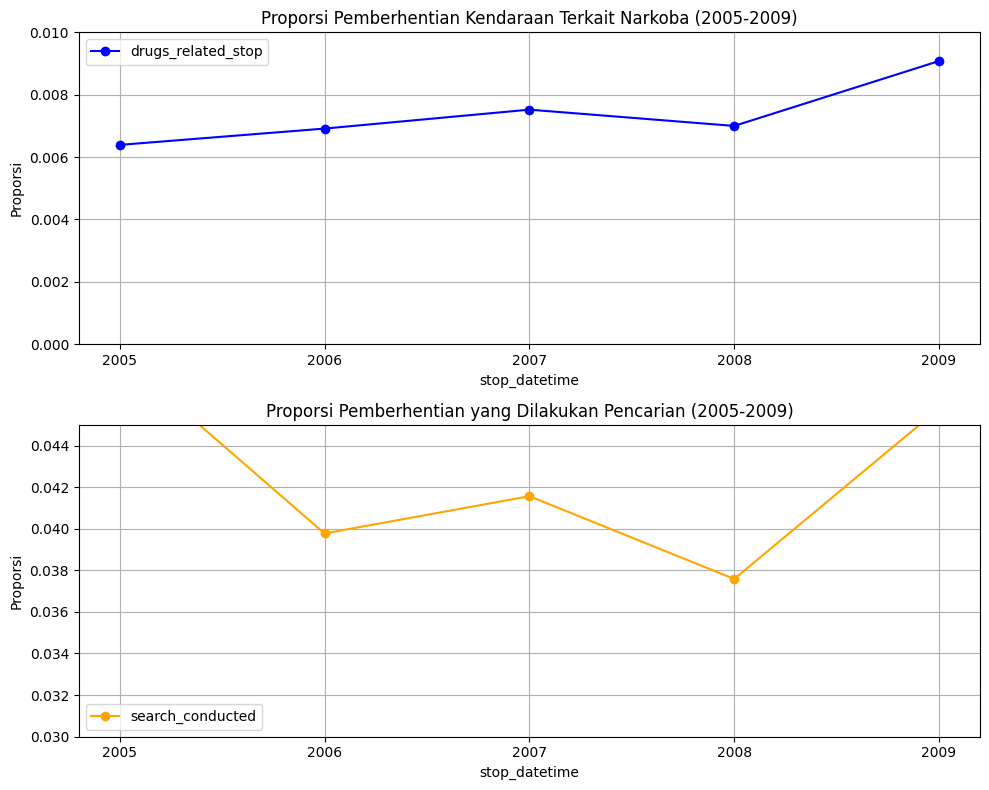

In [ ]:
# Bagian F
# Mengubah kolom 'stop_date' menjadi datetime
data['stop_date'] = pd.to_datetime(data['stop_date'])

# Mengambil tahun dari kolom 'stop_date'
data['year'] = data['stop_date'].dt.year

# Menghitung proporsi 'drugs_related_stop' dan 'search_conducted' per tahun
drugs_related = data.groupby('year')['drugs_related_stop'].mean()
search_conducted = data.groupby('year')['search_conducted'].mean()

# Memfilter data untuk tahun 2005 sampai 2009
drugs_related = drugs_related.loc[2005:2009]
search_conducted = search_conducted.loc[2005:2009]

# Membuat grafik
plt.figure(figsize=(10, 8))

# Grafik untuk drugs_related_stop
plt.subplot(2, 1, 1)
plt.plot(drugs_related.index, drugs_related.values, marker='o', color='blue', label='drugs_related_stop')
plt.title('Proporsi Pemberhentian Kendaraan Terkait Narkoba (2005-2009)')
plt.xlabel('stop_datetime')
plt.ylabel('Proporsi')
plt.xticks(drugs_related.index)  # Menampilkan tahun di sumbu x
plt.ylim(0.0, 0.01)  # Mengatur batas sumbu y untuk drugs_related_stop
plt.grid()
plt.legend()

# Grafik untuk search_conducted
plt.subplot(2, 1, 2)
plt.plot(search_conducted.index, search_conducted.values, marker='o', color='orange', label='search_conducted')
plt.title('Proporsi Pemberhentian yang Dilakukan Pencarian (2005-2009)')
plt.xlabel('stop_datetime')
plt.ylabel('Proporsi')
plt.xticks(search_conducted.index)  # Menampilkan tahun di sumbu x
plt.ylim(0.030, 0.045)  # Mengatur batas sumbu y untuk search_conducted
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

Grafik ini menunjukkan dua proporsi yang berkaitan dengan penegakan hukum terkait narkoba antara tahun 2005 hingga 2009.

Proporsi Pemberhentian Kendaraan Terkait Narkoba: Garis biru menunjukkan tren proporsi pemberhentian kendaraan yang terkait dengan narkoba. Terlihat bahwa terdapat fluktuasi dalam proporsinya selama periode tersebut, dengan beberapa tahun menunjukkan peningkatan.
Proporsi Pemberhentian yang Dilakukan Pencarian: Garis oranye menunjukkan proporsi pemberhentian di mana pencarian dilakukan. Meskipun ada variasi, garis ini menunjukkan tren yang lebih stabil dibandingkan dengan pemberhentian terkait narkoba.

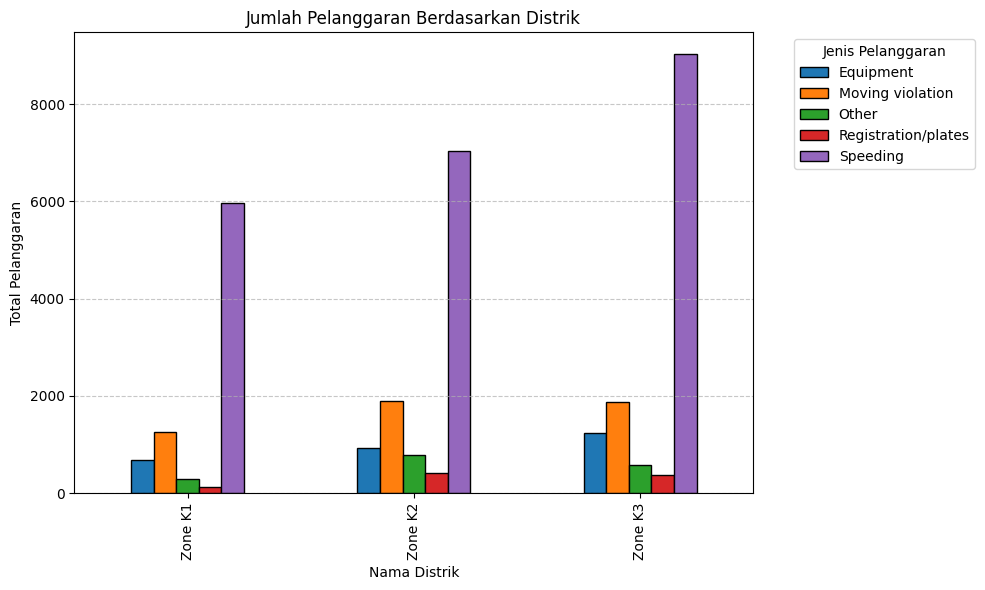

In [7]:
# Bagian G
# Menghitung jumlah pelanggaran berdasarkan distrik dan jenis pelanggaran
pelanggaran_distrik = data.pivot_table(index='district', columns='violation', aggfunc='size', fill_value=0)

# Mengurutkan distrik dengan benar (Zone K1, Zone K2, Zone K3)
urutkan_distrik = ['Zone K1', 'Zone K2', 'Zone K3']
pelanggaran_distrik = pelanggaran_distrik.reindex(urutkan_distrik)

# Membuat grafik batang dengan gaya yang berbeda
plt.figure(figsize=(10, 6))
pelanggaran_distrik[['Equipment', 'Moving violation', 'Other', 'Registration/plates', 'Speeding']].plot(
    kind='bar',
    stacked=False,
    ax=plt.gca(),
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'],
    edgecolor='black'  # Menambahkan garis tepi untuk setiap batang
)

# Menambahkan judul dan label
plt.title('Jumlah Pelanggaran Berdasarkan Distrik')
plt.xlabel('Nama Distrik')
plt.ylabel('Total Pelanggaran')
plt.legend(title='Jenis Pelanggaran', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Menambahkan garis grid pada sumbu y
plt.tight_layout()
plt.show()

Grafik ini menggambarkan jumlah pelanggaran berdasarkan distrik dan jenis pelanggaran. Terlihat bahwa kategori "Speeding" secara signifikan mendominasi jumlah pelanggaran, terutama di zona K3, di mana jumlahnya sangat tinggi dibandingkan kategori lainnya. Kategori "Moving violation" dan "Equipment" memiliki jumlah yang lebih rendah, sementara "Registration/plates" dan "Other" hampir tidak terlihat. Hasil ini menunjukkan bahwa pelanggaran kecepatan adalah masalah utama yang perlu ditangani di wilayah tersebut.

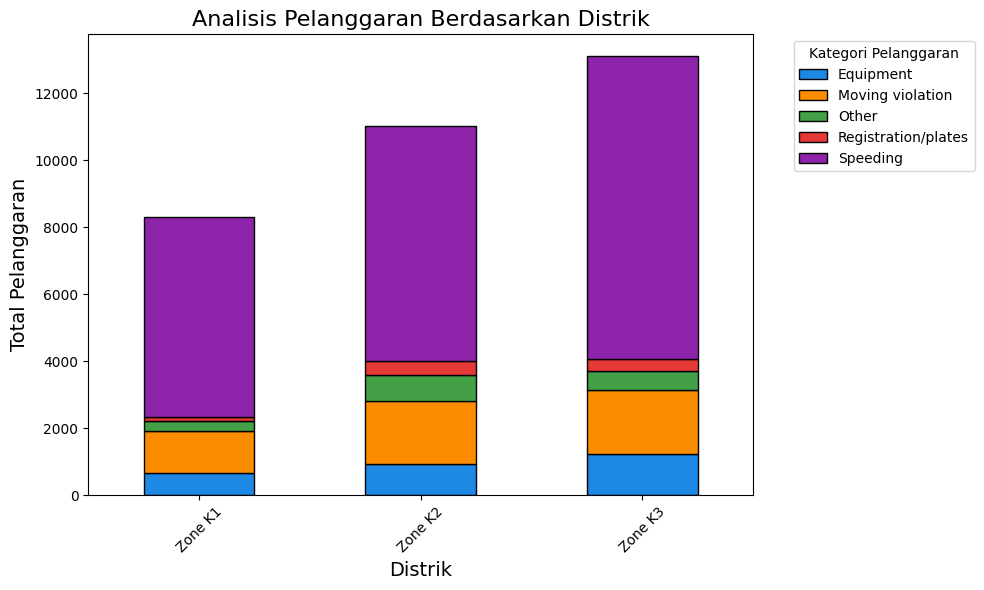

In [9]:
# Bagian H
# Mengelompokkan data berdasarkan distrik dan jenis pelanggaran, lalu menghitung totalnya
total_pelanggaran_per_distrik = data.groupby(['district', 'violation']).size().unstack(fill_value=0)

# Mengatur urutan distrik sesuai yang diinginkan
urutan_distrik = ['Zone K1', 'Zone K2', 'Zone K3']
total_pelanggaran_per_distrik = total_pelanggaran_per_distrik.reindex(urutan_distrik)

# Menentukan skema warna baru
skema_warna = ['#1E88E5', '#FB8C00', '#43A047', '#E53935', '#8E24AA', '#3949AB']

# Membuat grafik batang tumpuk
fig, ax = plt.subplots(figsize=(10, 6))  # Menggunakan subplots untuk kontrol lebih baik
total_pelanggaran_per_distrik.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=skema_warna,
    edgecolor='black'
)

# Menambahkan elemen pada grafik
ax.set_title('Analisis Pelanggaran Berdasarkan Distrik', fontsize=16)
ax.set_xlabel('Distrik', fontsize=14)
ax.set_ylabel('Total Pelanggaran', fontsize=14)
ax.legend(title='Kategori Pelanggaran', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

# Menampilkan grafik
plt.tight_layout()
plt.show()

Grafik ini menunjukkan analisis pelanggaran berdasarkan distrik, dengan fokus pada total pelanggaran di masing-masing zona (K2 dan K3). Dari visualisasi, terlihat bahwa pelanggaran kategori "Speeding" mendominasi di semua distrik, diikuti oleh kategori "Moving violation" dan "Equipment". Kategori lain, seperti "Registration/plates" dan "Other", memiliki jumlah yang lebih sedikit. Ini mengindikasikan bahwa kecepatan berlebih merupakan masalah utama di wilayah tersebut, yang mungkin memerlukan perhatian khusus dalam penegakan hukum.


Dari analisis beberapa grafik yang telah dibahas, beberapa kesimpulan dapat diambil:

Tren Penegakan Hukum Terkait Narkoba: Grafik pertama menunjukkan bahwa proporsi pemberhentian kendaraan terkait narkoba mengalami fluktuasi selama periode 2005 hingga 2009, dengan beberapa tahun menunjukkan peningkatan. Ini mengindikasikan bahwa penegakan hukum terhadap pelanggaran narkoba mungkin dipengaruhi oleh berbagai faktor, termasuk kebijakan atau kampanye tertentu.

Pemberhentian dan Pencarian: Terdapat hubungan antara jumlah pemberhentian kendaraan dan tindakan pencarian. Meskipun proporsi pencarian relatif stabil, peningkatan dalam pemberhentian menunjukkan bahwa ada fokus yang lebih besar pada penegakan hukum.

Tren Penangkapan Berdasarkan Waktu: Grafik terakhir menunjukkan fluktuasi tingkat penangkapan sepanjang hari. Puncak yang terlihat pada waktu-waktu tertentu bisa menunjukkan periode ketika aktivitas kriminal lebih tinggi, yang mungkin berkaitan dengan faktor sosial, ekonomi, atau kegiatan komunitas.

# **Kesimpulan Umum:**

Secara keseluruhan, data menunjukkan bahwa penegakan hukum terkait narkoba dan penangkapan memiliki pola yang dipengaruhi oleh waktu dan mungkin oleh kebijakan yang berlaku. Peningkatan dalam pemberhentian kendaraan dan variabilitas dalam tingkat penangkapan dapat memberikan wawasan penting bagi pengambil kebijakan dan aparat penegak hukum dalam merumuskan strategi yang lebih efektif.